C:\Users\Luiz Augusto\AppData\Local\Temp\ipykernel_14592\451372797.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


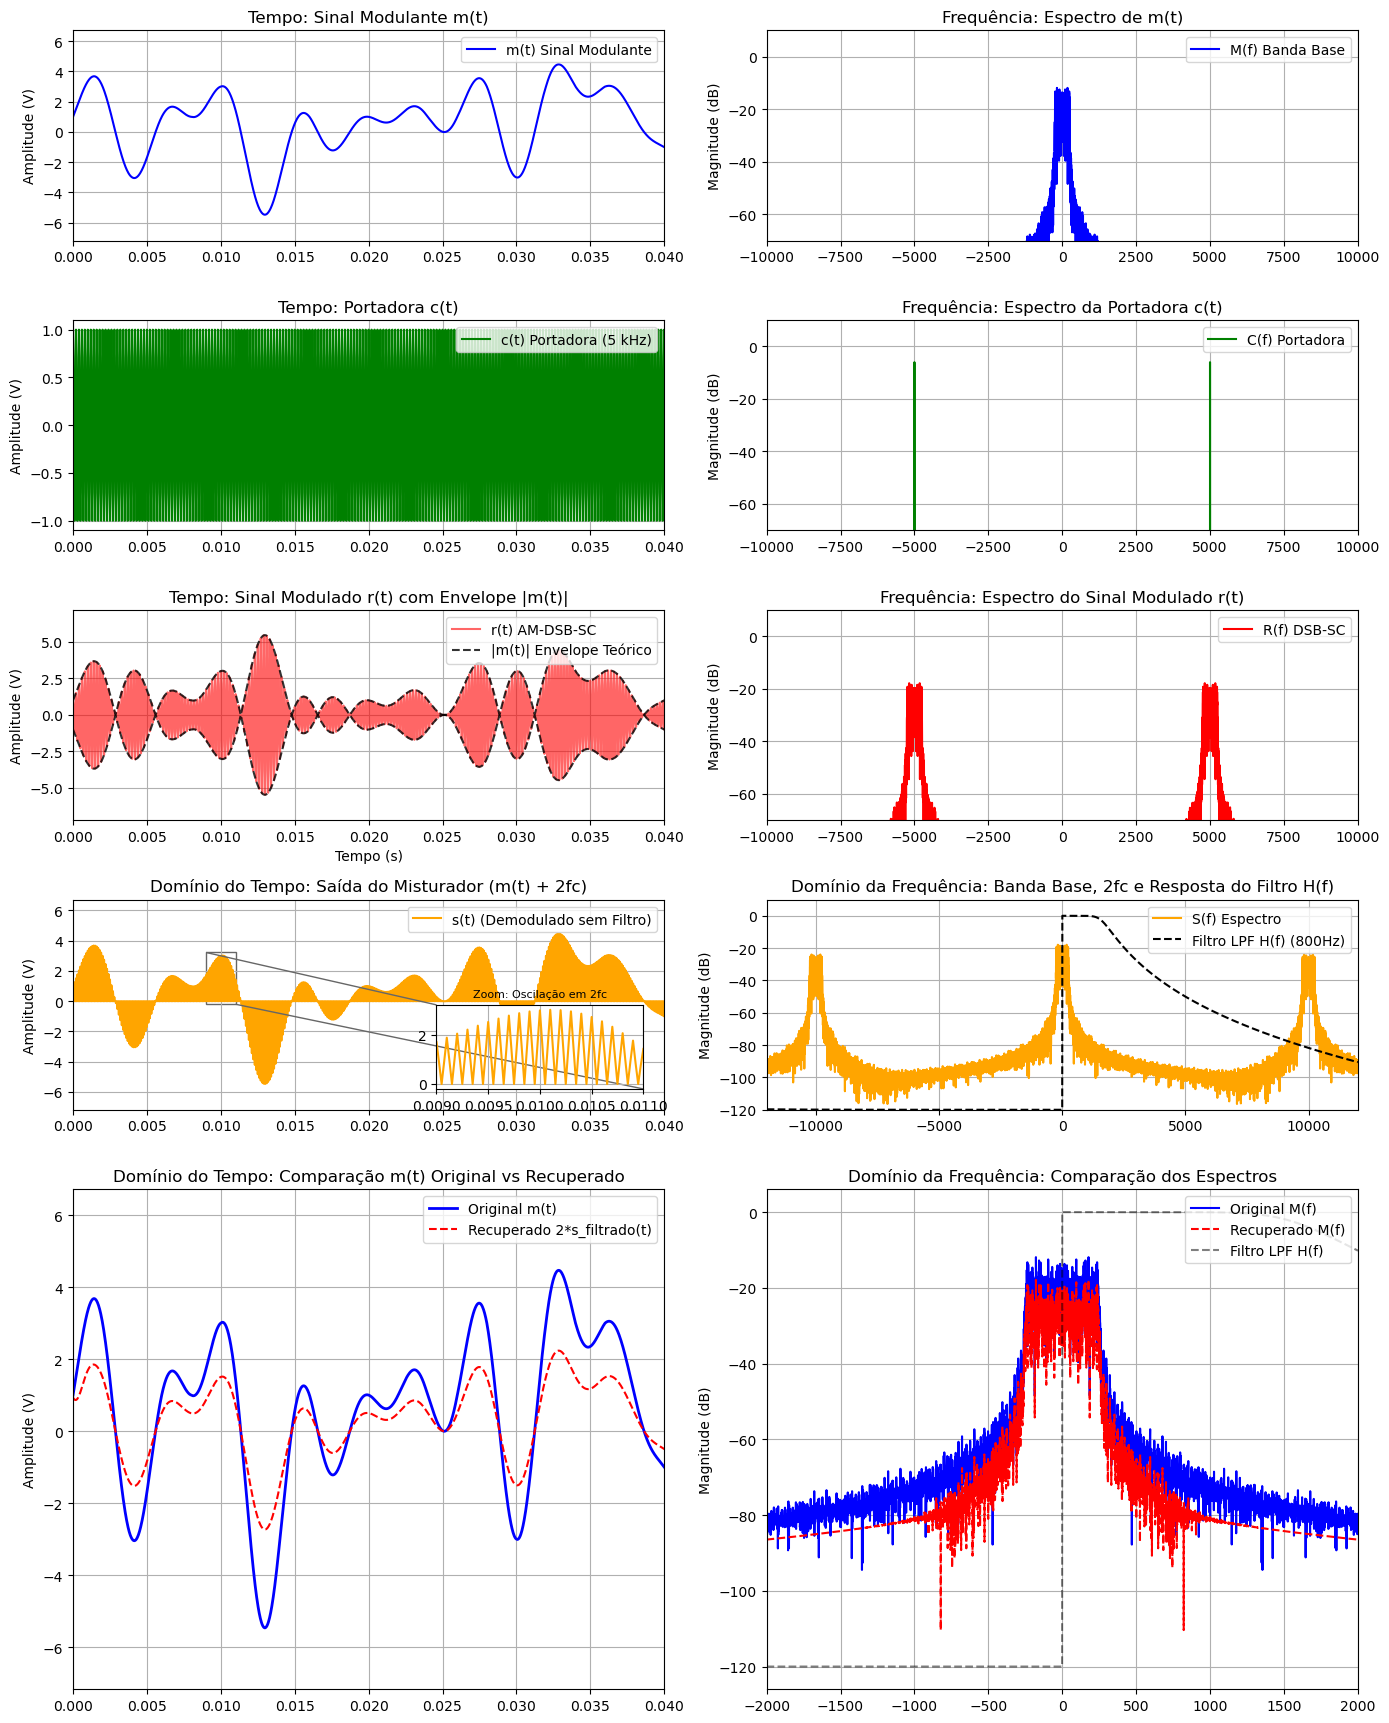

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.signal import butter, filtfilt, freqz
from scipy.fft import fft, fftshift, fftfreq

#-------------------------------------------------------------------------------------------------
# --- 1. Parâmetros e Geração do Sinal ---
#-------------------------------------------------------------------------------------------------
fs = 40000                      # Frequência de amostragem
T_sym = 0.002                   # Período do símbolo
num_symbols = 500               # Número de símbolos
t = np.arange(0, num_symbols * T_sym, 1/fs)

np.random.seed(42)
symbols = np.random.choice([-3, -1, 1, 3], num_symbols)
m_t = np.zeros_like(t)

for i, sym in enumerate(symbols):
    t_center = i * T_sym
    idx = (t > t_center - 10*T_sym) & (t < t_center + 10*T_sym)
    m_t[idx] += sym * np.sinc((t[idx] - t_center) / T_sym)

#-------------------------------------------------------------------------------------------------
# --- 2. Modulação (AM-DSB-SC) ---
#-------------------------------------------------------------------------------------------------
fc = 5000                       # Portadora de 5kHz
c_t = np.cos(2 * np.pi * fc * t)
r_t = m_t * c_t                 # Sinal modulado

#-------------------------------------------------------------------------------------------------
# Nesse ponto, teriámos a transmissão sem fio, a qual estamos considerando ser ideal neste exemplo
#--------------------------------------------------------------------------------------------------

#-------------------------------------------------------------------------------------------------
# --- 3. Demodulação e Filtragem ---
s_t = r_t * c_t 

cutoff = 800                    # Frequência de corte do filtro passa-baixas
nyq = 0.5 * fs
b, a = butter(5, cutoff / nyq, btype='low')

# Multiplicado por 2 para compensar o fator 1/2 da demodulação coerente
m_recuperado = filtfilt(b, a, s_t)
#-------------------------------------------------------------------------------------------------



# Resposta em frequência do filtro Passa-Baixas
w, h = freqz(b, a, worN=len(t), fs=fs)
h_db = 20 * np.log10(np.abs(h) + 1e-6)
f_filt = fftshift(fftfreq(len(t), 1/fs))
h_db_shifted = fftshift(h_db)

# Erro de reconstrução
erro_t = m_t - m_recuperado

# --- 4. Análise Espectral ---
def get_spectrum(signal, fs):
    n = len(signal)
    freqs = fftshift(fftfreq(n, 1/fs))
    spectrum = fftshift(np.abs(fft(signal)) / n)
    db_spectrum = 20 * np.log10(spectrum + 1e-6) 
    return freqs, db_spectrum

f, M_f = get_spectrum(m_t, fs)
_, C_f = get_spectrum(c_t, fs)
_, R_f = get_spectrum(r_t, fs)
_, S_f = get_spectrum(s_t, fs)
_, M_rec_f = get_spectrum(m_recuperado, fs)
_, E_f = get_spectrum(erro_t, fs)

# --- 5. Plotagem dos Gráficos ---
fig = plt.figure(figsize=(14, 20))
gs = GridSpec(7, 2, figure=fig)

# Coluna da Esquerda: Tempo
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t, m_t, 'b', label='m(t) Sinal Modulante')
ax1.set_xlim(0, 0.04)
ax1.set_ylabel('Amplitude (V)')
ax1.set_title('Tempo: Sinal Modulante m(t)')
ax1.legend(loc='upper right')
ax1.grid(True)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(t, c_t, 'g', label='c(t) Portadora (5 kHz)')
ax2.set_xlim(0, 0.04)
ax2.set_ylabel('Amplitude (V)')
ax2.set_title('Tempo: Portadora c(t)')
ax2.legend(loc='upper right')
ax2.grid(True)

# ax3: Sinal Modulado + Envelope Teórico |m(t)|
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(t, r_t, 'r', alpha=0.6, label='r(t) AM-DSB-SC')
ax3.plot(t, np.abs(m_t), 'k--', alpha=0.8, label='|m(t)| Envelope Teórico')
ax3.plot(t, -np.abs(m_t), 'k--', alpha=0.8)
ax3.set_xlim(0, 0.04)
ax3.set_xlabel('Tempo (s)')
ax3.set_ylabel('Amplitude (V)')
ax3.set_title('Tempo: Sinal Modulado r(t) com Envelope |m(t)|')
ax3.legend(loc='upper right')
ax3.grid(True)

# Coluna da Direita: Frequência
ax4 = fig.add_subplot(gs[0, 1])
ax4.plot(f, M_f, 'b', label='M(f) Banda Base')
ax4.set_title('Frequência: Espectro de m(t)')
ax4.set_ylabel('Magnitude (dB)')
ax4.set_xlim(-10000, 10000)
ax4.set_ylim(-70, 10)
ax4.legend(loc='upper right')
ax4.grid(True)

ax4_c = fig.add_subplot(gs[1, 1])
ax4_c.plot(f, C_f, 'g', label='C(f) Portadora')
ax4_c.set_title('Frequência: Espectro da Portadora c(t)')
ax4_c.set_ylabel('Magnitude (dB)')
ax4_c.set_xlim(-10000, 10000)
ax4_c.set_ylim(-70, 10)
ax4_c.legend(loc='upper right')
ax4_c.grid(True)

ax4_r = fig.add_subplot(gs[2, 1])
ax4_r.plot(f, R_f, 'r', label='R(f) DSB-SC')
ax4_r.set_title('Frequência: Espectro do Sinal Modulado r(t)')
ax4_r.set_ylabel('Magnitude (dB)')
ax4_r.set_xlim(-10000, 10000)
ax4_r.set_ylim(-70, 10)
ax4_r.legend(loc='upper right')
ax4_r.grid(True)

# Linha 3: Saída do Misturador (Com Zoom Inset e Resposta H(f))
ax5 = fig.add_subplot(gs[3, 0])
ax5.plot(t, s_t, 'orange', label='s(t) (Demodulado sem Filtro)')
ax5.set_xlim(0, 0.04)
ax5.set_title('Domínio do Tempo: Saída do Misturador (m(t) + 2fc)')
ax5.set_ylabel('Amplitude (V)')
ax5.legend(loc='upper right')
ax5.grid(True)

axins = inset_axes(ax5, width="35%", height="40%", loc='lower right', borderpad=1.5)
axins.plot(t, s_t, 'orange')
x1, x2 = 0.009, 0.011 
axins.set_xlim(x1, x2)
y_zoom = s_t[(t >= x1) & (t <= x2)]
axins.set_ylim(y_zoom.min() - 0.2, y_zoom.max() + 0.2)
axins.set_title('Zoom: Oscilação em 2fc', fontsize=8)
axins.grid(True)
mark_inset(ax5, axins, loc1=2, loc2=4, fc="none", ec="0.4")

# ax6: Espectro S(f) + Filtro LPF H(f)
ax6 = fig.add_subplot(gs[3, 1])
ax6.plot(f, S_f, 'orange', label='S(f) Espectro')
ax6.plot(f_filt, h_db_shifted, 'k--', lw=1.5, label=f'Filtro LPF H(f) ({cutoff}Hz)')
ax6.set_title('Domínio da Frequência: Banda Base, 2fc e Resposta do Filtro H(f)')
ax6.set_xlim(-12000, 12000)
ax6.set_ylim(-120, 10)
ax6.set_ylabel('Magnitude (dB)')
ax6.legend(loc='upper right')
ax6.grid(True)

# Linhas 4 e 5: Comparação dos Sinais Original e Recuperado
ax7 = fig.add_subplot(gs[4:6, 0])
ax7.plot(t, m_t, 'b', lw=2, label='Original m(t)')
ax7.plot(t, m_recuperado, 'r--', lw=1.5, label='Recuperado 2*s_filtrado(t)')
ax7.set_xlim(0, 0.04)
ax7.set_title('Domínio do Tempo: Comparação m(t) Original vs Recuperado')
ax7.set_ylabel('Amplitude (V)')
ax7.legend(loc='upper right')
ax7.grid(True)

# ax8: Espectro M(f) vs M_rec(f) + Curva do Filtro H(f)
ax8 = fig.add_subplot(gs[4:6, 1])
ax8.plot(f, M_f, 'b', label='Original M(f)')
ax8.plot(f, M_rec_f, 'r--', label='Recuperado M(f)')
ax8.plot(f_filt, h_db_shifted, 'k--', alpha=0.5, label='Filtro LPF H(f)')
ax8.set_title('Domínio da Frequência: Comparação dos Espectros')
ax8.set_xlim(-2000, 2000)
ax8.set_ylabel('Magnitude (dB)')
ax8.legend(loc='upper right')
ax8.grid(True)



plt.tight_layout()
plt.show()